<img src="Logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº7
#### Santiago Boente

En este trabajo práctico tuvimos como finalidad generar múltiples filtros que serán aplicados a una señal de ECG para que se asemeje a los latidos promedio en cuanto a  suavidad de los trazos y nivel isoeléctrico nulo. Para esto diseñaremos distintos filtros FIR e IIR y compararemos los resultados:


En primer lugar, usando los resultados de la TS5, estableceremos una plantilla de diseño con los siguientes parámetros:






In [89]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

# ======================================
# FILTRO
# ======================================

ws1 = .1
wp1 = 2
wp2 = 35
ws2 = 45
wp = [wp1, wp2]
ws = [ws1, ws2]
gpass = 1     # dB
gstop = 40     # dB

fs = 1000

Ahora generaremos los filtros IIR, usaremos el Butterworth, el Cauer y el Chebyshev 2:

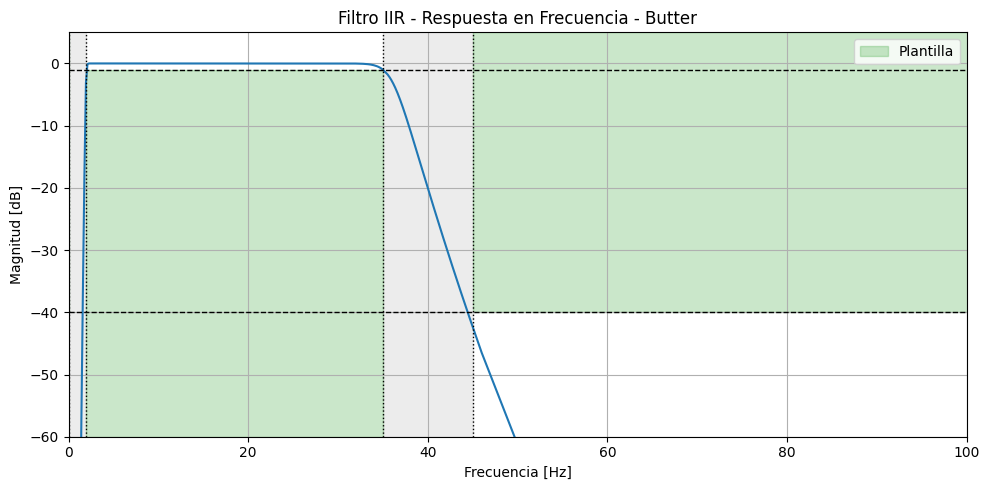

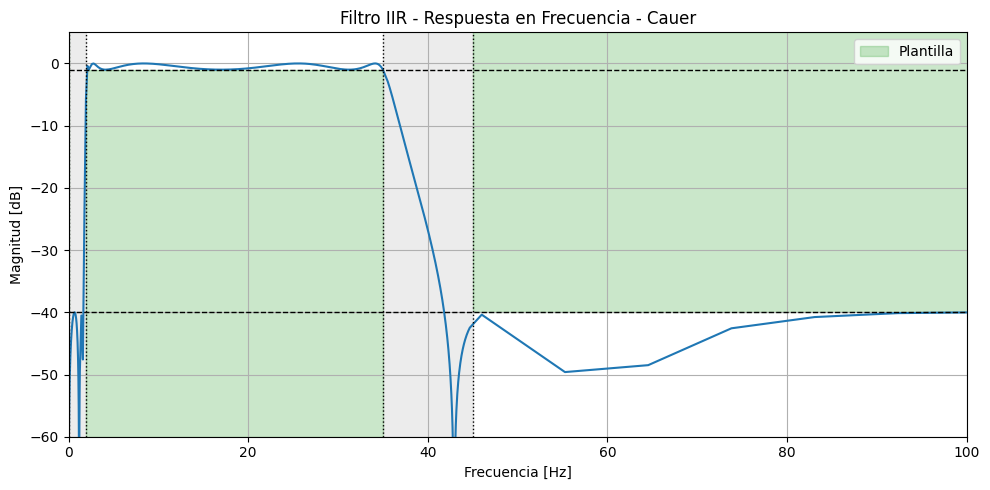

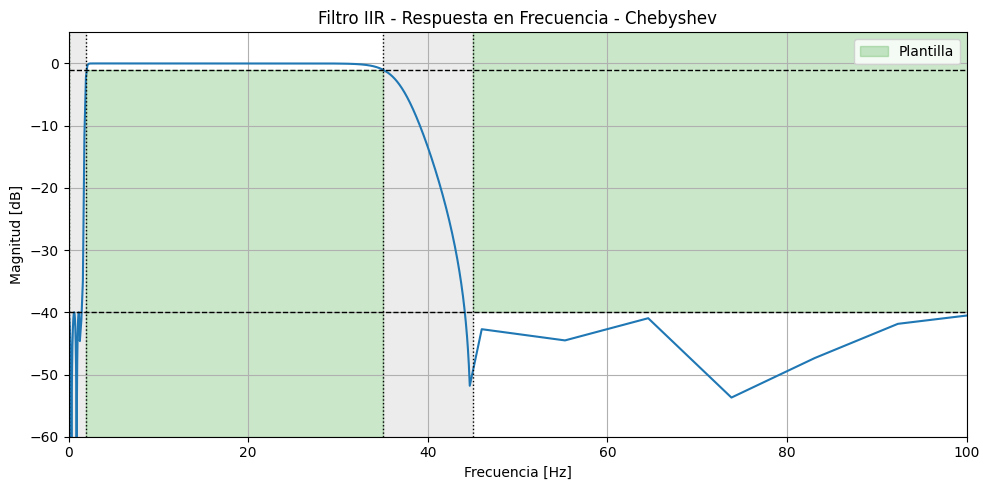

In [90]:
sos_butter = signal.iirdesign(wp,ws,gpass,gstop,analog=False,ftype='butter',output='sos',fs=fs)

sos_cauer = signal.iirdesign(wp,ws,gpass,gstop,analog=False,ftype='cauer',output='sos',fs=fs)

sos_cheby2 = signal.iirdesign(wp,ws,gpass,gstop,analog=False,ftype='cheby2',output='sos',fs=fs)

ww = np.concatenate([np.logspace(start =-2, stop = 0.1, num = 500),
               np.linspace(start = 1.26, stop = 35, num = 200),
               np.logspace(start = 1.55, stop = 1.65, num = 300),
               np.linspace(start = 46, stop = fs//2, num = 50)])

freqsbut, resp_freqbut = signal.sosfreqz(sos_butter, worN=ww, fs=fs)

# ======================================
# FIGURA para filtros IIR
# ======================================

plt.figure(figsize=(10,5))
plt.title('Filtro IIR - Respuesta en Frecuencia - Butter')

plt.plot(freqsbut,20*np.log10(np.abs(resp_freqbut) + 1e-12),color='C0')
plt.ylabel("Magnitud [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.grid(True)

# =====================================================
# PLANTILLA
# =====================================================

fmin = 0
fmax = fs/2

plt.fill_between([0, ws1], -gstop, 5, color='C2', alpha=0.25)
plt.fill_between([ws1, wp1], -60, 5, color='gray', alpha=0.15)
plt.fill_between([wp1, wp2], -60, -gpass, color='C2', alpha=0.25, label='Plantilla')
plt.fill_between([wp2, ws2], -60, 5, color='gray', alpha=0.15)
plt.fill_between([ws2, fmax], -gstop, 5, color='C2', alpha=0.25)

# Líneas de referencia
plt.axhline(-gpass, color='k', linestyle='--', linewidth=1)
plt.axhline(-gstop, color='k', linestyle='--', linewidth=1)

plt.axvline(ws1, color='k', linestyle=':', linewidth=1)
plt.axvline(wp1, color='k', linestyle=':', linewidth=1)
plt.axvline(wp2, color='k', linestyle=':', linewidth=1)
plt.axvline(ws2, color='k', linestyle=':', linewidth=1)

plt.xlim(0, 100)
plt.ylim(-60, 5)

plt.legend()
plt.tight_layout()
plt.show()


freqscau, resp_freqcau = signal.sosfreqz(sos_cauer, worN=ww, fs=fs)

# ======================================
# FIGURA para filtros IIR
# ======================================

plt.figure(figsize=(10,5))
plt.title('Filtro IIR - Respuesta en Frecuencia - Cauer')

plt.plot(freqscau,20*np.log10(np.abs(resp_freqcau) + 1e-12),color='C0')
plt.ylabel("Magnitud [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.grid(True)

# =====================================================
# PLANTILLA
# =====================================================

fmin = 0
fmax = fs/2

plt.fill_between([fmin, ws1], -gstop, 5, color='C2', alpha=0.25)
plt.fill_between([ws1, wp1], -60, 5, color='gray', alpha=0.15)
plt.fill_between([wp1, wp2], -60, -gpass, color='C2', alpha=0.25, label='Plantilla')
plt.fill_between([wp2, ws2], -60, 5, color='gray', alpha=0.15)
plt.fill_between([ws2, fmax], -gstop, 5, color='C2', alpha=0.25)

# Líneas de referencia
plt.axhline(-gpass, color='k', linestyle='--', linewidth=1)
plt.axhline(-gstop, color='k', linestyle='--', linewidth=1)

plt.axvline(ws1, color='k', linestyle=':', linewidth=1)
plt.axvline(wp1, color='k', linestyle=':', linewidth=1)
plt.axvline(wp2, color='k', linestyle=':', linewidth=1)
plt.axvline(ws2, color='k', linestyle=':', linewidth=1)

plt.xlim(0, 100)
plt.ylim(-60, 5)

plt.legend()
plt.tight_layout()
plt.show()


freqscheb, resp_freqcheb = signal.sosfreqz(sos_cheby2, worN=ww, fs=fs)

# ======================================
# FIGURA para filtros IIR
# ======================================

plt.figure(figsize=(10,5))
plt.title('Filtro IIR - Respuesta en Frecuencia - Chebyshev')

plt.plot(freqscheb,20*np.log10(np.abs(resp_freqcheb)+ 1e-12),color='C0')
plt.ylabel("Magnitud [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.grid(True)

# =====================================================
# PLANTILLA
# =====================================================

fmin = 0
fmax = fs/2

plt.fill_between([fmin, ws1], -gstop, 5, color='C2', alpha=0.25)
plt.fill_between([ws1, wp1], -60, 5, color='gray', alpha=0.15)
plt.fill_between([wp1, wp2], -60, -gpass, color='C2', alpha=0.25, label='Plantilla')
plt.fill_between([wp2, ws2], -60, 5, color='gray', alpha=0.15)
plt.fill_between([ws2, fmax], -gstop, 5, color='C2', alpha=0.25)

# Líneas de referencia
plt.axhline(-gpass, color='k', linestyle='--', linewidth=1)
plt.axhline(-gstop, color='k', linestyle='--', linewidth=1)

plt.axvline(ws1, color='k', linestyle=':', linewidth=1)
plt.axvline(wp1, color='k', linestyle=':', linewidth=1)
plt.axvline(wp2, color='k', linestyle=':', linewidth=1)
plt.axvline(ws2, color='k', linestyle=':', linewidth=1)

plt.xlim(0, 100)
plt.ylim(-60, 5)

plt.legend()
plt.tight_layout()
plt.show()


Podemos observar que todos los filtros cumplen con lo requerido en las plantillas. El filtro Butterworth presentó una respuesta monótona y suave, sin ondulaciones, aunque con una transición menos abrupta entre la banda de paso y la banda eliminada. El filtro Cauer fue el más selectivo, logrando una transición más rápida y cumpliendo la plantilla con menor orden, a costa de presentar ripple en la banda de paso y en la banda eliminada. El filtro Chebyshev 2 mostró un comportamiento intermedio: mantiene una banda de paso sin ripple, pero presenta ondulaciones en la banda eliminada y una transición más abrupta que Butterworth.

Ahora evaluaremos la ECG, evaluando regiones clave:

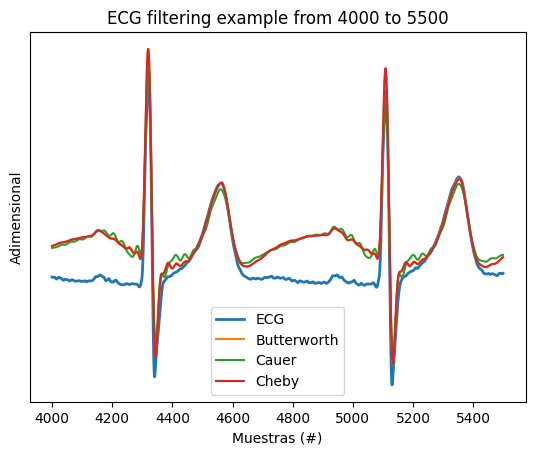

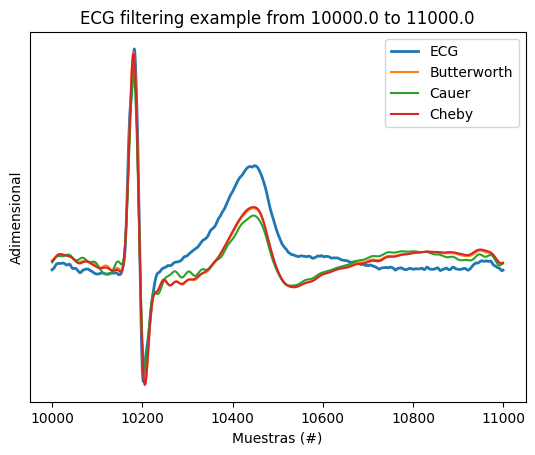

In [91]:
import scipy.io as sio
from scipy.io.wavfile import write

##################
# Lectura de ECG #
##################

fs_ecg = 1000 # Hz

##################
## ECG con ruido
##################

# para listar las variables que hay en el archivo
sio.whosmat('ECG_TP4.mat')
mat_struct = sio.loadmat('ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead'].flatten()
cant_muestras = len(ecg_one_lead)

ECG_f_butt = signal.sosfiltfilt(sos_butter, ecg_one_lead)
ECG_f_cauer = signal.sosfiltfilt(sos_cauer, ecg_one_lead)
ECG_f_cheby2 = signal.sosfiltfilt(sos_cheby2, ecg_one_lead)
 
fs_ecg = 1000

tt = np.arange(len(ecg_one_lead)) / fs_ecg

###################################
#%% Regiones de interes sin ruido #
###################################    

regs_interes = ([4000, 5500],
                [10e3, 11e3])



for ii in regs_interes:

    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]),np.min([cant_muestras, ii[1]]),dtype='uint')

    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region],label='ECG',linewidth=2)
    plt.plot(zoom_region,ECG_f_butt[zoom_region],label='Butterworth')
    plt.plot(zoom_region,ECG_f_cauer[zoom_region],label='Cauer')
    plt.plot(zoom_region,ECG_f_cheby2[zoom_region],label='Cheby')
    #plt.plot(zoom_region,ECG_f_win[zoom_region - demora],label='FIR Window')
    plt.title('ECG filtering example from ' +str(ii[0]) +' to ' +str(ii[1]))
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
    plt.show()
    

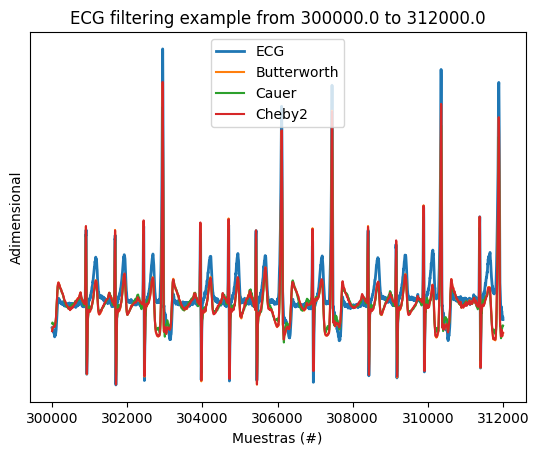

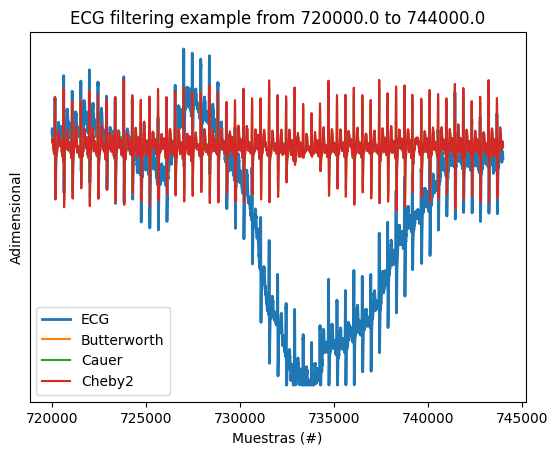

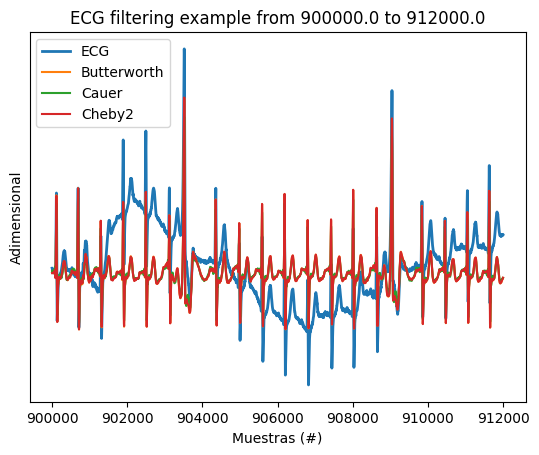

In [92]:
###################################
# Regiones de interes con ruido   #
###################################    
    
    
regs_interes = (
    np.array([5, 5.2]) * 60 * fs,   # minutos a muestras
    np.array([12, 12.4]) * 60 * fs, # minutos a muestras
    np.array([15, 15.2]) * 60 * fs  # minutos a muestras
)

for ii in regs_interes:

    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]),np.min([cant_muestras, ii[1]]),dtype='uint')

    plt.figure()
    plt.plot(zoom_region,ecg_one_lead[zoom_region],label='ECG',linewidth=2)
    plt.plot(zoom_region,ECG_f_butt[zoom_region],label='Butterworth')
    plt.plot(zoom_region,ECG_f_cauer[zoom_region],label='Cauer')
    plt.plot(zoom_region,ECG_f_cheby2[zoom_region],label='Cheby2')
    #plt.plot(zoom_region,ECG_f_win[zoom_region - demora],label='FIR Window')
    plt.title('ECG filtering example from '+ str(ii[0]) +' to ' +str(ii[1]))
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())


    plt.show()

En el caso de las regiones sin ruido, se puede observar como los filtros conservan correctamente la forma de la señal. En cambio, en las regiones con ruido se observa una clara diferencia, mostrando como los ruidos corrigen la señal.

Ahora analizaremos los filtros FIR, usando boxcar y cuadrados minimos. Usando un diseño de plantilla distinto:

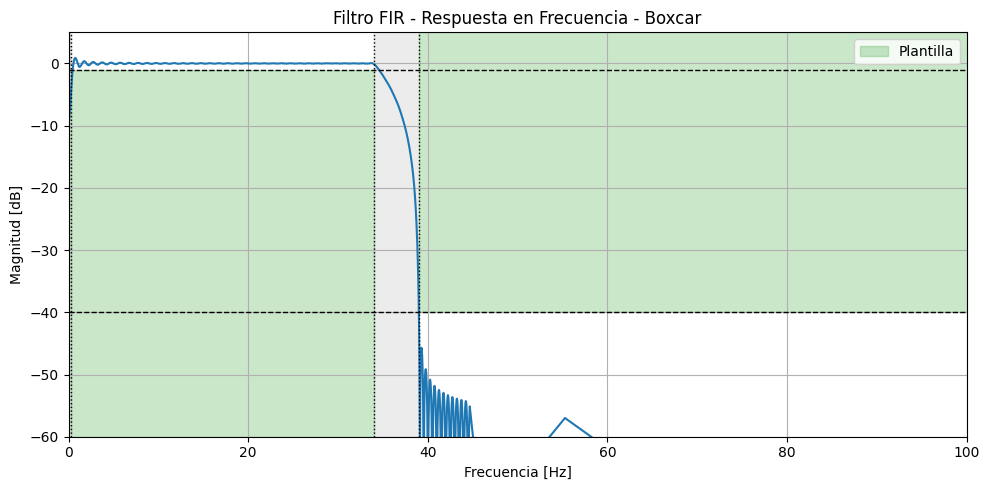

In [93]:
# ======================================
# FILTRO
# ======================================

ws1 = .1
wp1 = .3
wp2 = 34
ws2 = 39
wp = [wp1, wp2]
ws = [ws1, ws2]
gpass = 1     # dB
gstop = 40     # dB

fs = 1000

numtaps = 2001

gains = np.array([0, 0, 1, 1, 0, 0])

gains[-1] = 0.0


#FILTROS FIR
b_win = signal.firwin2(numtaps, freq = np.array([0, ws1, wp1, wp2, ws2, fs//2]), gain = gains, window = 'boxcar', fs = fs)

w, h = signal.freqz(b_win, worN = ww, fs = fs)

# ======================================
# FIGURA para filtros FIR
# ======================================

plt.figure(figsize=(10,5))
plt.title('Filtro FIR - Respuesta en Frecuencia - Boxcar')

plt.plot(w,20*np.log10(np.maximum(np.abs(h), 1e-12)),color='C0')

plt.ylabel("Magnitud [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.grid(True)

# =====================================================
# PLANTILLA
# =====================================================

fmin = 0
fmax = fs/2

plt.fill_between([fmin, ws1], -gstop, 5, color='C2', alpha=0.25)
plt.fill_between([ws1, wp1], -60, 5, color='gray', alpha=0.15)
plt.fill_between([wp1, wp2], -60, -gpass, color='C2', alpha=0.25, label='Plantilla')
plt.fill_between([wp2, ws2], -60, 5, color='gray', alpha=0.15)
plt.fill_between([ws2, fmax], -gstop, 5, color='C2', alpha=0.25)

# Líneas de referencia
plt.axhline(-gpass, color='k', linestyle='--', linewidth=1)
plt.axhline(-gstop, color='k', linestyle='--', linewidth=1)

plt.axvline(ws1, color='k', linestyle=':', linewidth=1)
plt.axvline(wp1, color='k', linestyle=':', linewidth=1)
plt.axvline(wp2, color='k', linestyle=':', linewidth=1)
plt.axvline(ws2, color='k', linestyle=':', linewidth=1)

plt.xlim(0, 100)
plt.ylim(-60, 5)

plt.legend()
plt.tight_layout()
plt.show()


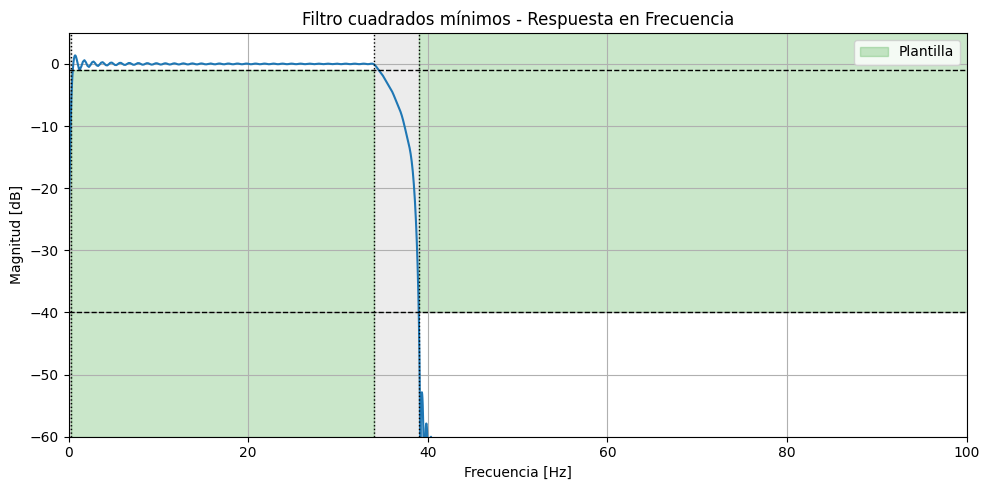

In [94]:
numtaps2 = 2001

cuad_min = signal.firls(
    numtaps2,
    np.array([0, ws1, ws1, wp1, wp1, wp2, wp2, ws2, ws2, fs//2]),
    desired=[0, 0, 0, 1, 1, 1, 1, 0, 0, 0],
    weight=[10, 1, 1, 1, 10],
    fs=fs
)

zmin, pmin, kmin = signal.tf2zpk(cuad_min, a=1)

freqsmin, resp_freqmin = signal.freqz(cuad_min, worN=ww, fs=fs)

# ======================================
# FIGURA para filtros cuadrados mínimos
# ======================================

plt.figure(figsize=(10,5))
plt.title('Filtro cuadrados mínimos - Respuesta en Frecuencia')

plt.plot(
    freqsmin,
    20*np.log10(np.maximum(np.abs(resp_freqmin), 1e-12)),
    color='C0'
)

plt.ylabel("Magnitud [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.grid(True)

# =====================================================
# PLANTILLA
# =====================================================

fmin = 0
fmax = fs/2

plt.fill_between([fmin, ws1], -gstop, 5, color='C2', alpha=0.25)
plt.fill_between([ws1, wp1], -60, 5, color='gray', alpha=0.15)
plt.fill_between([wp1, wp2], -60, -gpass, color='C2', alpha=0.25, label='Plantilla')
plt.fill_between([wp2, ws2], -60, 5, color='gray', alpha=0.15)
plt.fill_between([ws2, fmax], -gstop, 5, color='C2', alpha=0.25)

# Líneas de referencia
plt.axhline(-gpass, color='k', linestyle='--', linewidth=1)
plt.axhline(-gstop, color='k', linestyle='--', linewidth=1)

plt.axvline(ws1, color='k', linestyle=':', linewidth=1)
plt.axvline(wp1, color='k', linestyle=':', linewidth=1)
plt.axvline(wp2, color='k', linestyle=':', linewidth=1)
plt.axvline(ws2, color='k', linestyle=':', linewidth=1)

plt.xlim(0, 100)
plt.ylim(-60, 5)

plt.legend()
plt.tight_layout()
plt.show()

El filtro con ventana rectangular logra la forma general deseada, aunque puede presentar mayor ripple debido a las características de la ventana utilizada. En cambio, el método de cuadrados mínimos permite distribuir el error de aproximación de forma más controlada, y mediante el uso de pesos se prioriza la atenuación en las bandas eliminadas.

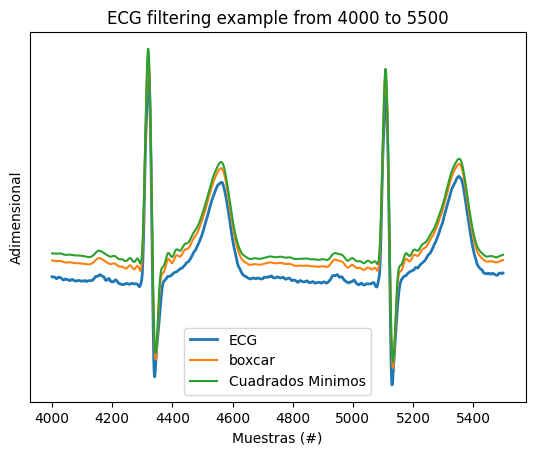

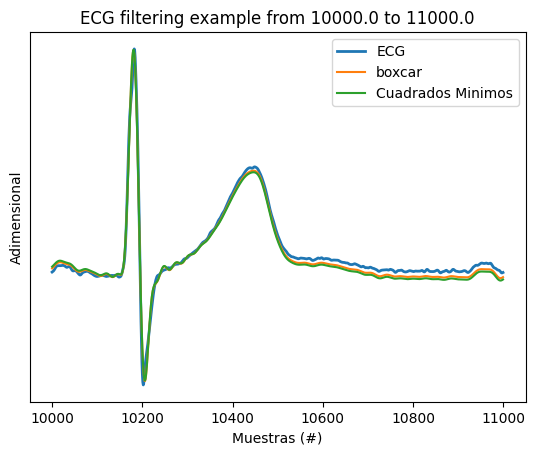

In [95]:
ECG_f_box = signal.lfilter(b_win, 1., ecg_one_lead)
ECG_f_cuad = signal.lfilter(cuad_min, 1., ecg_one_lead)

regs_interes = ([4000, 5500],
                [10e3, 11e3])

demora = (numtaps - 1)//2

for ii in regs_interes:

    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]),np.min([cant_muestras, ii[1]]),dtype='uint')

    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region],label='ECG',linewidth=2)
    plt.plot(zoom_region,ECG_f_box[zoom_region + demora],label='boxcar')
    plt.plot(zoom_region,ECG_f_cuad[zoom_region + demora],label='Cuadrados Minimos')
    plt.title('ECG filtering example from ' +str(ii[0]) +' to ' +str(ii[1]))
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
    plt.show()

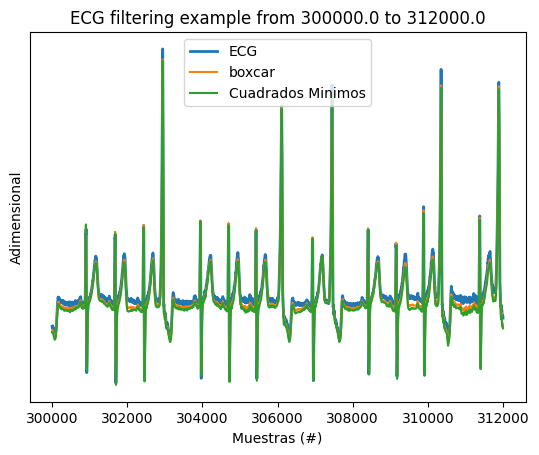

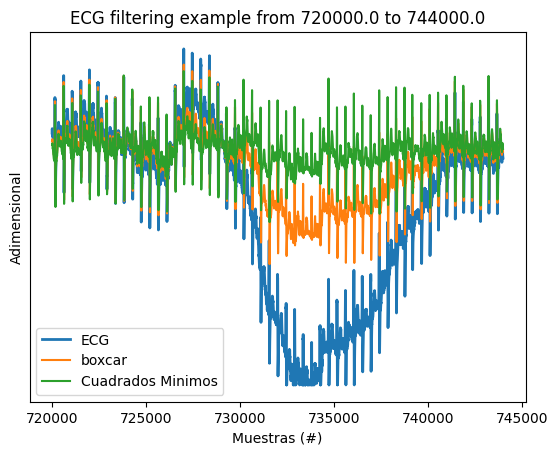

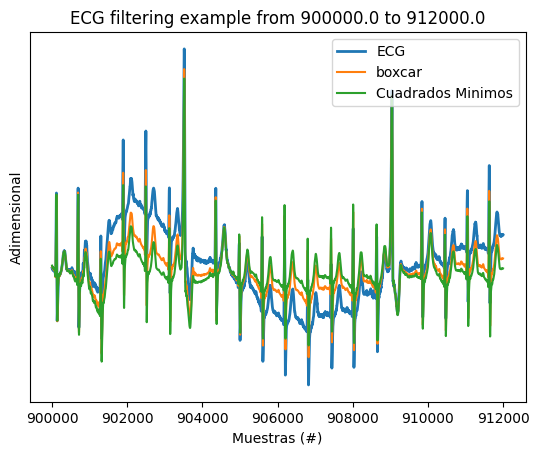

In [96]:
###################################
# Regiones de interes con ruido   #
###################################    
    
    
regs_interes = (
    np.array([5, 5.2]) * 60 * fs,   # minutos a muestras
    np.array([12, 12.4]) * 60 * fs, # minutos a muestras
    np.array([15, 15.2]) * 60 * fs  # minutos a muestras
)

for ii in regs_interes:

    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]),np.min([cant_muestras, ii[1]]),dtype='uint')

    plt.figure()
    plt.plot(zoom_region,ecg_one_lead[zoom_region],label='ECG',linewidth=2)
    plt.plot(zoom_region,ECG_f_box[zoom_region + demora],label='boxcar')
    plt.plot(zoom_region,ECG_f_cuad[zoom_region + demora],label='Cuadrados Minimos')
    #plt.plot(zoom_region,ECG_f_win[zoom_region - demora],label='FIR Window')
    plt.title('ECG filtering example from '+ str(ii[0]) +' to ' +str(ii[1]))
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())


    plt.show()

Se puede observar como ambos filtros funcionan correctamente y logran corregir en su mayoria los problemas de la ECG.

#### Conclusión


En este trabajo práctico se diseñaron y compararon distintos filtros digitales aplicados al procesamiento de una señal ECG. Analizandose filtros IIR y FIR y observando sus diferencias. Los filtros utilizados lograron cumplir su función, ayudando a conservar la forma de la ECG, mejorando la calidad general de la señal y facilitando la visualización de sus componentes principales. Aun así, se comprobó que la elección del filtro debe realizarse cuidadosamente, ya que un filtrado excesivo o mal ajustado puede eliminar información útil o deformar características importantes de la señal biomédica.